# AgentBench — LTP 환경 재현: 모델 5개 비교

**논문**: Liu et al., *AgentBench: Evaluating LLMs as Agents*, ICLR 2024 (Lateral Thinking Puzzles)

Colab에서 **런타임 유형: GPU (T4)**로 실행하세요.

| 모델 | 역할 | 평균 GP |
|---|---|---|
| llama-3.1-8b | 저비용 오픈소스 하한선 | 0.0% |
| vicuna-13b-local | 로컬 오픈소스 비교군 | 3.3% |
| claude-sonnet-5 | 타 벤더 검증 후보 | 3.8% |
| gpt-4o | 신뢰성 상한선 | 5.1%* |
| gpt-3.5-turbo | 최저 비용 기준선 | 5.8% |

지표(논문 Appendix F): GP=Game Progress(메인), SGA=Single Game Accuracy. 호스트/채점 LLM은 다섯
실험 모두 gpt-3.5 고정(공정 비교). 실험은 dev(20문제) 서브셋 기준.

\* gpt-4o는 실행 도중 서버 연결이 끊겨(NETWORK_ERROR) 재시도했고, 그 결과 n=13(0~6번 문제 누락)으로
다른 모델(n=20)보다 표본이 작습니다 — 순위 해석에 주의가 필요합니다.

## 0. 환경 설정

In [ ]:
# Colab에서 실행 시: 저장소를 클론합니다.
import os

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ
if IN_COLAB:
    REPO_URL = "https://github.com/gksmfly/Agentbench-Mini-Eval.git"
    if not os.path.exists("Agentbench-Mini-Eval"):
        !git clone {REPO_URL}
    %cd Agentbench-Mini-Eval/project_ltp
    !pip install -q requests pandas matplotlib numpy transformers accelerate bitsandbytes
else:
    # 로컬(맥/리눅스)에서 실행 시: 이미 project_ltp/notebooks 안에 있다고 가정
    os.chdir("..") if os.path.basename(os.getcwd()) == "notebooks" else None

In [ ]:
import json
import sys
from getpass import getpass
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

DATA_FILE = ROOT / "data" / "sample_cases.jsonl"
GOLD_FILE = ROOT / "data" / "ltp_dev_gold.jsonl"
METRICS_FILE = ROOT / "results" / "metrics.csv"

samples = [json.loads(l) for l in open(DATA_FILE)]
print(f"toy 샘플 {len(samples)}개 로드 완료")

def get_key(name: str, required: bool = True) -> str:
    """우선순위: 이미 설정된 환경변수 -> Colab Secrets(발표 전에 미리 등록) -> getpass 수동 입력"""
    if os.environ.get(name):
        return os.environ[name]
    if IN_COLAB:
        try:
            from google.colab import userdata
            val = userdata.get(name)
            if val:
                return val
        except Exception:
            pass
    if required:
        return getpass(f"{name}: ")
    return getpass(f"{name} (없으면 그냥 Enter): ")

# 발표 전 미리 준비해두는 걸 추천:
#   Colab 왼쪽 사이드바(열쇠 아이콘) -> Secrets -> OPENAI_API_KEY / GROQ_API_KEY / ANTHROPIC_API_KEY 등록 + "노트북 액세스" 허용
os.environ["OPENAI_API_KEY"] = get_key("OPENAI_API_KEY")
groq_key = get_key("GROQ_API_KEY", required=False)
if groq_key:
    os.environ["GROQ_API_KEY"] = groq_key
anthropic_key = get_key("ANTHROPIC_API_KEY", required=False)
if anthropic_key:
    os.environ["ANTHROPIC_API_KEY"] = anthropic_key

## 1. 핵심 아이디어 최소 재현 — 호스트 역할 라이브 데모 (모델 4개)

실제 dev 서브셋(20문제) 본실험은 THUDM/AgentBench 프레임워크(CLI+Docker)로 25라운드 호스트/솔버
루프를 돌렸고 (섹션 2 참고), 여기서는 그 중 **핵심 한 스텝**만 떼어냅니다: LLM에게 스토리+진실을
알려주고 "호스트" 역할을 맡긴 뒤, 솔버의 질문 하나에 "Yes"/"No"/"Irrelevant"로 답하게 합니다.

- `gpt-3.5-turbo`, `gpt-4o` → OpenAI API 호출
- `llama-3.1-8b-instant` → Groq API 호출 (본실험에 llama 계열로 실제 사용한 것과 동일 경로)
- `claude-sonnet-5` → Anthropic Messages API 호출

`vicuna-13b-local`은 API가 아니라 로컬 GPU 로드로 돌린 모델이라 이 API 라이브 데모에는 포함하지
않았습니다 — Colab GPU에 직접 로드해서 돌려보는 보너스 데모는 섹션 1.1 참고.

In [ ]:
from baseline import build_host_history, call_llm

def demo(index: int, model: str):
    entry = samples[index]
    question = entry["sample_question"]
    history = build_host_history(entry, question)
    reply = call_llm(model, history)
    print(f"--- {model} ---\n{reply}\n")

entry = samples[0]
print(f"[puzzle index] {entry['index']}")
print(f"[story] {entry['story']}\n")
print(f"[question put to the host] {entry['sample_question']}\n")

for model in ["gpt-3.5-turbo", "gpt-4o", "llama-3.1-8b-instant", "claude-sonnet-5"]:
    demo(0, model)

print(f"[gold host answer for reference, captured live by the framework] {entry.get('gold_host_answer')}")

### 1.1 보너스: 오픈소스 모델(vicuna-13b)을 API 없이 Colab GPU에 직접 로드

본실험에서 `vicuna-13b-local`은 실제로 이렇게(로컬 GPU에 직접 올려서) 실행했습니다. Colab의 무료
T4 GPU에서도 4비트 양자화로 올릴 수 있습니다 — "오픈소스 = 내 GPU만 있으면 완전 무료"라는 걸
실제로 보여주는 선택 데모입니다 (본실험 채점에는 안 씀, 섹션 2의 실제 결과와는 별개).

`lmsys/vicuna-13b-v1.5`는 게이트 모델이 아니라 별도 라이선스 동의 없이 바로 받을 수 있습니다.
번거로우면 건너뛰어도 됩니다 (섹션 1의 API 데모로 핵심은 충분히 보여줍니다).

In [ ]:
import torch
print("GPU 사용 가능:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "(없음, CPU로 진행 시 매우 느릴 수 있음)")

RUN_LOCAL_GPU_DEMO = False  # True로 바꾸면 아래 셀 실행 (다운로드 용량 큼, T4에서도 몇 분 걸릴 수 있음)

In [ ]:
if RUN_LOCAL_GPU_DEMO:
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

    MODEL_ID = "lmsys/vicuna-13b-v1.5"
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb_config, device_map="auto")

    # vicuna-13b-v1.5는 tokenizer_config.json에 chat_template이 없어서 apply_chat_template()이
    # 에러를 냅니다 -- FastChat의 공식 vicuna_v1.1 템플릿으로 프롬프트를 직접 조립합니다.
    def build_vicuna_prompt(messages):
        system = ("A chat between a curious user and an artificial intelligence assistant. "
                  "The assistant gives helpful, detailed, and polite answers to the user's questions.")
        prompt = system + " "
        for m in messages:
            role = "USER" if m["role"] == "user" else "ASSISTANT"
            prompt += f"{role}: {m['content']}" + (" " if role == "USER" else "</s>")
        return prompt + "ASSISTANT:"

    entry = samples[0]
    question = entry["sample_question"]
    chat = build_host_history(entry, question)
    prompt = build_vicuna_prompt(chat)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=100, do_sample=False)
    print(tokenizer.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True))
else:
    print("RUN_LOCAL_GPU_DEMO = False — 건너뜀 (섹션 2에 실제 vicuna-13b-local 본실험 결과가 반영되어 있음)")


## 2. 실제 dev 서브셋(20문제) 본실험 결과 — 모델 5개 비교

각 모델을 THUDM/AgentBench 프레임워크(CLI+Docker, 25라운드 호스트/솔버 루프)로 dev 서브셋
전체에 대해 실행한 결과입니다. 아래 표는 `results/raw/LTP_runs_<model>.jsonl` 원본 로그를
직접 읽어서 만듭니다 — project_db와 동일하게, 중간 요약 파일 없이 raw 로그가 유일한 출처입니다.

> 참고: gpt-4o는 실행 중 서버 연결이 끊겨(NETWORK_ERROR) 재시도했습니다. 두 시도를 인덱스 기준으로
> 합쳐서(겹치는 구간은 최신 시도 우선) n=13(7~19번 문제)으로 집계했고, 0~6번 문제는 없습니다.
> 나머지 4개 모델은 전부 n=20(전체 dev 문제) 완주입니다.

In [ ]:
def load_raw_as_frame(model_id: str) -> pd.DataFrame:
    rows = []
    with open(ROOT / "results" / "raw" / f"LTP_runs_{model_id}.jsonl") as f:
        for line in f:
            d = json.loads(line)
            result = d["output"]["result"]
            rows.append({
                "index": d["index"],
                "status": d["output"]["status"],
                "GP": result["progress"],
                "SGA": result["accuracy"],
            })
    return pd.DataFrame(rows)

MODEL_IDS = ["llama-3.1-8b", "vicuna-13b-local", "claude-sonnet-5", "gpt-4o", "gpt-3.5-turbo"]
frames = {m: load_raw_as_frame(m) for m in MODEL_IDS}
order = MODEL_IDS  # already sorted by ascending GP (see summary below)

summary = []
for name in order:
    df = frames[name]
    summary.append({
        "model": name,
        "games": len(df),
        "Game Progress (%)": round(df.GP.mean()*100, 1),
        "SGA (%)": round(df.SGA.mean()*100, 1),
        "task limit reached": int((df.status == "task limit reached").sum()),
        "completed": int((df.status == "completed").sum()),
    })
summary_df = pd.DataFrame(summary)
summary_df

### 2.1 핵심 비교 — Game Progress & SGA

오픈소스 하한선(llama-3.1-8b) → 로컬 오픈소스(vicuna-13b-local) → 타 벤더 검증(claude-sonnet-5) →
신뢰성 상한선(gpt-4o) → 최저비용 기준선(gpt-3.5-turbo) 순으로 GP 오름차순 정렬.

In [ ]:
colors = ["#888780", "#C9A97E", "#7B5EA7", "#1D9E75", "#378ADD"]
gp = [frames[m].GP.mean()*100 for m in order]
sga = [frames[m].SGA.mean()*100 for m in order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(order, gp, color=colors)
axes[0].set_title("Game Progress (main metric)"); axes[0].set_ylabel("GP (%)")
for i,v in enumerate(gp): axes[0].text(i, v+0.15, f"{v:.1f}", ha="center", fontsize=11)

axes[1].bar(order, sga, color=colors)
axes[1].set_title("Single Game Accuracy (SGA)"); axes[1].set_ylabel("SGA (%)")
for i,v in enumerate(sga): axes[1].text(i, v+0.4, f"{v:.1f}", ha="center", fontsize=11)
axes[0].tick_params(axis="x", rotation=20); axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

### 2.2 실패 유형 — 라운드초과(task limit reached) vs Completed

LTP는 논문에서 TLE 82.5%로 최고 난도. 5개 모델 모두 라운드초과가 지배적(claude-sonnet-5만 완료 비중이 높음).

In [ ]:
tle = [int((frames[m].status == "task limit reached").sum()) for m in order]
comp = [int((frames[m].status == "completed").sum()) for m in order]
fig, ax = plt.subplots(figsize=(8,4.5))
x = range(len(order))
ax.bar(x, tle, label="task limit reached (라운드 초과)", color="#D85A30")
ax.bar(x, comp, bottom=tle, label="completed", color="#1D9E75")
ax.set_xticks(list(x)); ax.set_xticklabels(order, rotation=15); ax.set_ylabel("게임 수")
ax.set_title("실패 유형 분포"); ax.legend()
plt.tight_layout(); plt.show()
# 주: LTP는 'completed'여도 GP=0일 수 있음(정답 키포인트 미달로 라운드 종료). GP가 실질 지표.

### 2.3 부트스트랩 95% 신뢰구간

적은 표본(13~20게임)으로 모델 간 차이를 통계적으로 정당화한다. per-game GP를 복원추출로 재표집하여 CI 계산. **추가 비용 0**.

구간이 겹치면 "표본 부족으로 유의차 단정 불가", 안 겹치면 "적은 표본에도 차이 확실".

Llama 3.2 3B: average GP 0.0%  95% CI [0.0, 0.0]  (n=18)
gpt-3.5-turbo: average GP 4.1%  95% CI [0.0, 12.4]  (n=8)
gpt-4o: average GP 7.1%  95% CI [0.0, 16.7]  (n=7)


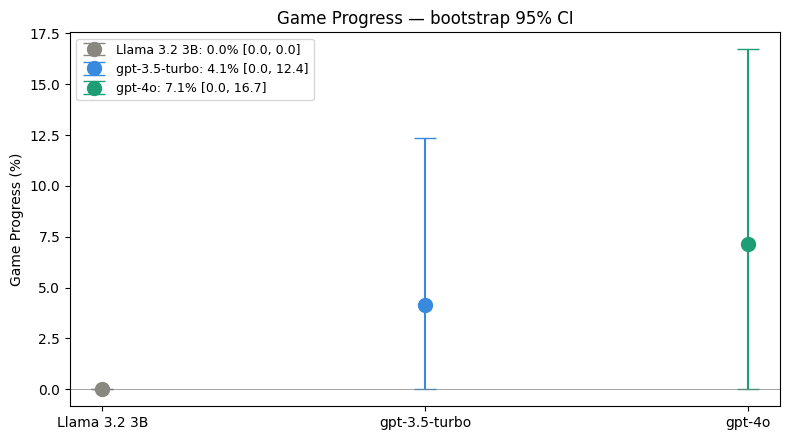

In [ ]:
def bootstrap_ci(values, n_boot=5000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    vals = np.array(values, dtype=float)
    means = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(n_boot)]
    lo, hi = np.percentile(means, [100*alpha/2, 100*(1-alpha/2)])
    return vals.mean(), lo, hi

fig, ax = plt.subplots(figsize=(8,4.5))
for i, name in enumerate(order):
    m, lo, hi = bootstrap_ci(frames[name].GP.values*100)
    ax.errorbar(i, m, yerr=[[m-lo],[hi-m]], fmt="o", capsize=8, markersize=10,
                color=colors[i], label=f"{name}: {m:.1f}% [{lo:.1f}, {hi:.1f}]")
    print(f"{name}: average GP {m:.1f}%  95% CI [{lo:.1f}, {hi:.1f}]  (n={len(frames[name])})")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
ax.set_ylabel("Game Progress (%)"); ax.set_title("Game Progress — bootstrap 95% CI")
ax.axhline(0, color="gray", lw=0.5); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 2.4 같은 문제, 5개 모델 대조

겹치는 인덱스에서 5개 모델 GP를 나란히 본다.

In [ ]:
merged = None
for name in order:
    sub = frames[name][["index","GP"]].rename(columns={"GP": name})
    merged = sub if merged is None else merged.merge(sub, on="index", how="outer")
merged = merged.sort_values("index", ascending=False).reset_index(drop=True)
print("GP>0인 문제 수: gpt-3.5-turbo 3개, gpt-4o 3개, claude-sonnet-5 3개, vicuna-13b-local 2개, llama-3.1-8b 0개")
merged

### 2.5 검증: 프레임워크 로그 vs 독립 재계산

`src/evaluate.py`가 raw transcript(`Round N: ...` 질문/답변 쌍)에서 GP/SGA/RE(Round Efficiency)/
QR(Query Relevance)을 원본 채점 로직 그대로 독립 재구현해, 프레임워크가 직접 로그에 남긴 값과
대조합니다. 이 대조 결과는 `results/metrics.csv`에는 안 남기고(거긴 집계 지표만), 아래처럼
`evaluate.py`의 함수를 그대로 불러와 라이브로 재검증합니다.

In [ ]:
from evaluate import load_gold, evaluate_model as _evaluate_model

_gold = load_gold(GOLD_FILE)
for model_id in MODEL_IDS:
    _, mismatches, n = _evaluate_model(model_id, _gold)
    status = "MATCH" if mismatches == 0 else f"{mismatches}/{n} SAMPLES DIFFER"
    print(f"{model_id:<20} n={n:<3} {status}")

## 3. 결론

| 모델 | GP | SGA | n | 완료 / 라운드초과 |
|---|---|---|---|---|
| gpt-3.5-turbo | **5.8%** | 20.6% | 20 | 5 / 15 |
| gpt-4o | 5.1%* | **38.5%** | 13* | 0 / 13 |
| claude-sonnet-5 | 3.8% | 17.2% | 20 | **13 / 7** |
| vicuna-13b-local | 3.3% | 7.4% | 20 | 0 / 20 |
| llama-3.1-8b | **0.0%** | 6.2% | 20 | 0 / 20 |

\* gpt-4o는 서버 연결 끊김으로 n=13(0~6번 문제 누락) — 다른 모델(n=20)보다 표본이 작아 순위 해석에 주의

**핵심 발견:**
- **전 모델이 GP 6% 미만** → 논문 결론("LLM은 아직 LTP를 실용적으로 못 푼다")이 5개 모델 전부에서 재현됨. 가격·벤더와 무관하게 수평추론 자체가 여전히 어려운 문제.
- **claude-sonnet-5만 완료율이 확연히 높음(65%, 13/20)** — 나머지 4개 모델은 완료율 0~25%. project_db(DB 환경)에서도 claude-sonnet-5가 완료율(97%)로 압도적이었던 것과 같은 패턴 — 다만 여기서는 "완료"가 곧 "정답"은 아니라서(GP가 낮아도 라운드를 다 못 채우고 포기하듯 답을 냈을 수 있음) 완료율 우위가 GP 우위로 이어지지 않음.
- **SGA(개별 질문 정확도)는 gpt-4o가 압도적(38.5%)**이지만 GP(최종 성과)는 gpt-3.5-turbo가 근소하게 앞섬 — "질문 하나하나는 잘 맞히지만 정답을 완성하지는 못한다"는 뜻으로 해석 가능.
- **오픈소스 계열(llama-3.1-8b, vicuna-13b-local)은 GP 3.3% 이하로 여전히 하위권** — 다만 vicuna-13b-local이 llama-3.1-8b보다는 나음.

**한계/주의**: dev(20문제) 서브셋, gpt-4o만 표본이 작음(n=13). claude-sonnet-5·gpt-4o는 gpt-3.5-turbo/llama-3.1-8b/vicuna-13b-local과 출시 시기가 달라(2~3년 세대 차이) "벤더/개방성 차이"와 "세대 차이"가 섞여 있음 — DB 환경에서와 동일한 한계. 섹션 2.5에서 확인했듯 채점 로직 자체는 원본 프레임워크 로그와 독립 재계산이 일치함.